In [1]:
# Bibliotecas para análise estatística

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
# Carregamento dos dados processados

from pathlib import Path

arquivo = Path("../data/processed/candidatos_2026.parquet")

df = pd.read_parquet(arquivo)

df.head()

,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,...,CD_ESTADO_CIVIL,estado_civil,CD_COR_RACA,cor_raca,CD_OCUPACAO,ocupacao,CD_SIT_TOT_TURNO,situacao_final,idade,tipo_cargo
0,24/08/2026,16:31:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,3,CASADO(A),3,PARDA,999,OUTROS,-1,Não informado,65,Legislativo
1,24/08/2026,16:31:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,3,CASADO(A),1,BRANCA,602,PECUARISTA,-1,Não informado,61,Legislativo
2,24/08/2026,16:31:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,1,SOLTEIRO(A),1,BRANCA,142,PROFESSOR DE ENSINO SUPERIOR,-1,Não informado,72,Legislativo
3,24/08/2026,16:31:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,1,SOLTEIRO(A),3,PARDA,931,"ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",-1,Não informado,31,Executivo
4,24/08/2026,16:31:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,3,CASADO(A),5,INDÍGENA,999,OUTROS,-1,Não informado,44,Legislativo


In [3]:
df.shape

(20721, 49)

In [4]:
df.columns.tolist()

['DT_GERACAO',
 'HH_GERACAO',
 'ANO_ELEICAO',
 'CD_TIPO_ELEICAO',
 'NM_TIPO_ELEICAO',
 'NR_TURNO',
 'CD_ELEICAO',
 'DS_ELEICAO',
 'DT_ELEICAO',
 'TP_ABRANGENCIA',
 'estado',
 'SG_UE',
 'estado_nome',
 'CD_CARGO',
 'cargo',
 'SQ_CANDIDATO',
 'NR_CANDIDATO',
 'nome_candidato',
 'nome_urna',
 'NM_SOCIAL_CANDIDATO',
 'CD_SITUACAO_CANDIDATURA',
 'DS_SITUACAO_CANDIDATURA',
 'TP_AGREMIACAO',
 'NR_PARTIDO',
 'partido',
 'nome_partido',
 'NR_FEDERACAO',
 'NM_FEDERACAO',
 'SG_FEDERACAO',
 'DS_COMPOSICAO_FEDERACAO',
 'SQ_COLIGACAO',
 'NM_COLIGACAO',
 'DS_COMPOSICAO_COLIGACAO',
 'SG_UF_NASCIMENTO',
 'DT_NASCIMENTO',
 'CD_GENERO',
 'genero',
 'CD_GRAU_INSTRUCAO',
 'escolaridade',
 'CD_ESTADO_CIVIL',
 'estado_civil',
 'CD_COR_RACA',
 'cor_raca',
 'CD_OCUPACAO',
 'ocupacao',
 'CD_SIT_TOT_TURNO',
 'situacao_final',
 'idade',
 'tipo_cargo']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20721 entries, 0 to 20720
Data columns (total 49 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   DT_GERACAO               20721 non-null  str           
 1   HH_GERACAO               20721 non-null  str           
 2   ANO_ELEICAO              20721 non-null  int64         
 3   CD_TIPO_ELEICAO          20721 non-null  int64         
 4   NM_TIPO_ELEICAO          20721 non-null  str           
 5   NR_TURNO                 20721 non-null  int64         
 6   CD_ELEICAO               20721 non-null  int64         
 7   DS_ELEICAO               20721 non-null  str           
 8   DT_ELEICAO               20721 non-null  str           
 9   TP_ABRANGENCIA           20721 non-null  str           
 10  estado                   20721 non-null  str           
 11  SG_UE                    20721 non-null  str           
 12  estado_nome              20721 non-null  st

In [6]:
# Verificação das principais variáveis categóricas

variaveis_categoricas = [
    "genero",
    "escolaridade",
    "estado_civil",
    "cor_raca"
]

for coluna in variaveis_categoricas:
    print(f"\n{coluna.upper()}")
    print(df[coluna].value_counts(dropna=False))


GENERO
genero
MASCULINO    13492
FEMININO      7229
Name: count, dtype: int64

ESCOLARIDADE
escolaridade
SUPERIOR COMPLETO                12136
ENSINO MÉDIO COMPLETO             4447
SUPERIOR INCOMPLETO               2190
ENSINO MÉDIO INCOMPLETO            722
ENSINO FUNDAMENTAL INCOMPLETO      615
ENSINO FUNDAMENTAL COMPLETO        536
LÊ E ESCREVE                        75
Name: count, dtype: int64

ESTADO_CIVIL
estado_civil
CASADO(A)                    10394
SOLTEIRO(A)                   7177
DIVORCIADO(A)                 2642
VIÚVO(A)                       317
SEPARADO(A) JUDICIALMENTE      191
Name: count, dtype: int64

COR_RACA
cor_raca
BRANCA      10281
PARDA        7320
PRETA        2818
INDÍGENA      194
AMARELA       108
Name: count, dtype: int64


In [7]:
# Tabela de contingência: gênero x escolaridade

tabela_genero_escolaridade = pd.crosstab(
    df["genero"],
    df["escolaridade"]
)

tabela_genero_escolaridade

escolaridade,ENSINO FUNDAMENTAL COMPLETO,ENSINO FUNDAMENTAL INCOMPLETO,ENSINO MÉDIO COMPLETO,ENSINO MÉDIO INCOMPLETO,LÊ E ESCREVE,SUPERIOR COMPLETO,SUPERIOR INCOMPLETO
genero,,,,,,,
FEMININO,151,182,1526,231,24,4343,772
MASCULINO,385,433,2921,491,51,7793,1418


In [8]:
# Teste do qui-quadrado de independência

qui2, p_valor, graus_liberdade, frequencias_esperadas = stats.chi2_contingency(
    tabela_genero_escolaridade
)

print(f"Qui-quadrado: {qui2:.4f}")
print(f"p-valor: {p_valor:.6f}")
print(f"Graus de liberdade: {graus_liberdade}")

Qui-quadrado: 26.2478
p-valor: 0.000200
Graus de liberdade: 6


In [10]:
# Frequências esperadas pelo teste

tabela_esperada = pd.DataFrame(
    frequencias_esperadas,
    index=tabela_genero_escolaridade.index,
    columns=tabela_genero_escolaridade.columns
)

tabela_esperada

escolaridade,ENSINO FUNDAMENTAL COMPLETO,ENSINO FUNDAMENTAL INCOMPLETO,ENSINO MÉDIO COMPLETO,ENSINO MÉDIO INCOMPLETO,LÊ E ESCREVE,SUPERIOR COMPLETO,SUPERIOR INCOMPLETO
genero,,,,,,,
FEMININO,186.995994,214.556971,1551.438782,251.886395,26.165484,4233.924231,764.032141
MASCULINO,349.004006,400.443029,2895.561218,470.113605,48.834516,7902.075769,1425.967859


In [11]:
# Cálculo do V de Cramér

n = tabela_genero_escolaridade.to_numpy().sum()

phi2 = qui2 / n

r, k = tabela_genero_escolaridade.shape

v_cramer = np.sqrt(
    phi2 / min(k - 1, r - 1)
)

print(f"V de Cramér: {v_cramer:.4f}")

V de Cramér: 0.0356


In [12]:
# Diferença entre frequências observadas e esperadas

residuos = (
    tabela_genero_escolaridade - tabela_esperada
)

residuos

escolaridade,ENSINO FUNDAMENTAL COMPLETO,ENSINO FUNDAMENTAL INCOMPLETO,ENSINO MÉDIO COMPLETO,ENSINO MÉDIO INCOMPLETO,LÊ E ESCREVE,SUPERIOR COMPLETO,SUPERIOR INCOMPLETO
genero,,,,,,,
FEMININO,-35.995994,-32.556971,-25.438782,-20.886395,-2.165484,109.075769,7.967859
MASCULINO,35.995994,32.556971,25.438782,20.886395,2.165484,-109.075769,-7.967859


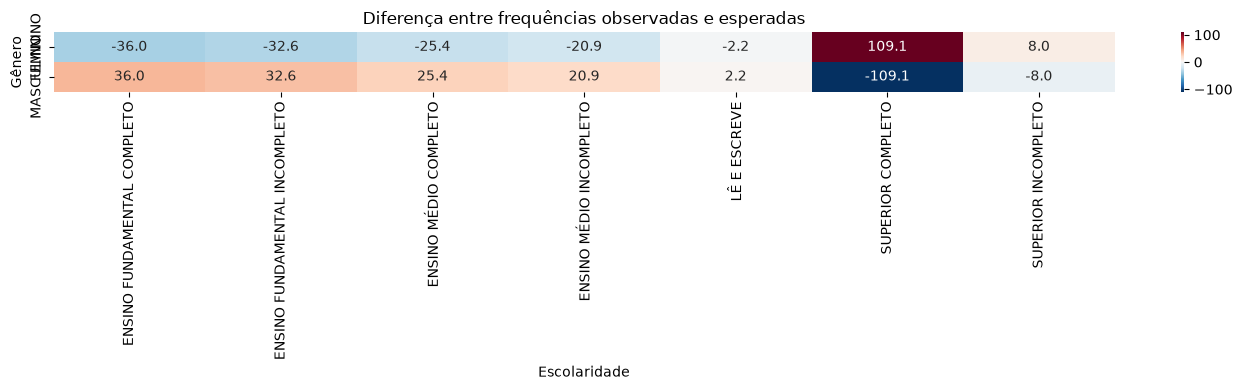

In [13]:
plt.figure(figsize=(14, 4))

sns.heatmap(
    residuos,
    annot=True,
    fmt=".1f",
    cmap="RdBu_r",
    center=0
)

plt.title("Diferença entre frequências observadas e esperadas")
plt.xlabel("Escolaridade")
plt.ylabel("Gênero")

plt.tight_layout()
plt.show()

In [14]:
# Resíduos padronizados

residuos_padronizados = (
    (tabela_genero_escolaridade - tabela_esperada)
    / np.sqrt(tabela_esperada)
)

residuos_padronizados

escolaridade,ENSINO FUNDAMENTAL COMPLETO,ENSINO FUNDAMENTAL INCOMPLETO,ENSINO MÉDIO COMPLETO,ENSINO MÉDIO INCOMPLETO,LÊ E ESCREVE,SUPERIOR COMPLETO,SUPERIOR INCOMPLETO
genero,,,,,,,
FEMININO,-2.632316,-2.222658,-0.645846,-1.316016,-0.423341,1.676319,0.288261
MASCULINO,1.926810,1.626948,0.472748,0.963301,0.309879,-1.227037,-0.211002


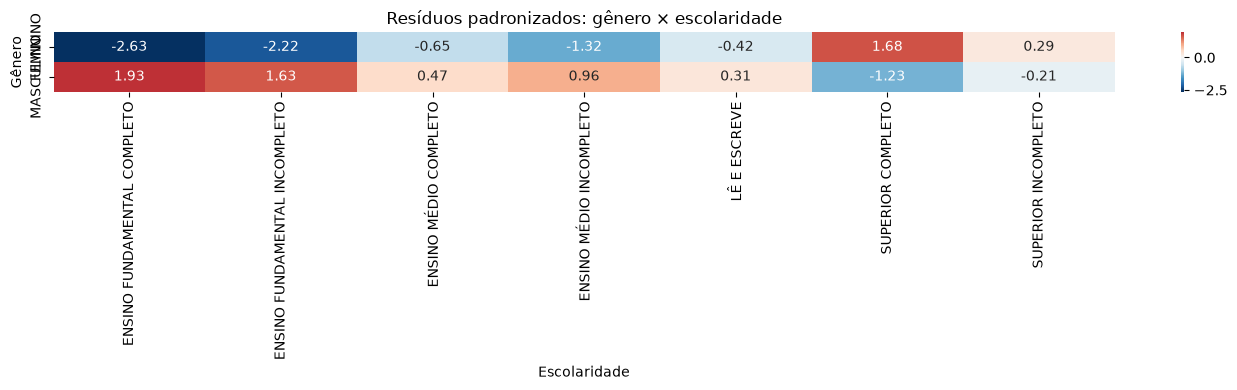

In [15]:
plt.figure(figsize=(14, 4))

sns.heatmap(
    residuos_padronizados,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0
)

plt.title("Resíduos padronizados: gênero × escolaridade")
plt.xlabel("Escolaridade")
plt.ylabel("Gênero")

plt.tight_layout()
plt.show()

In [16]:
# Estatísticas de idade por gênero

idade_genero = (
    df.groupby("genero")["idade"]
    .agg(
        Media="mean",
        Mediana="median",
        Minima="min",
        Maxima="max",
        Desvio_Padrao="std",
        Quantidade="count"
    )
    .reset_index()
)

idade_genero

,genero,Media,Mediana,Minima,Maxima,Desvio_Padrao,Quantidade
0,FEMININO,47.753493,47.0,19,92,11.277188,7229
1,MASCULINO,50.024607,49.0,20,92,11.879294,13492


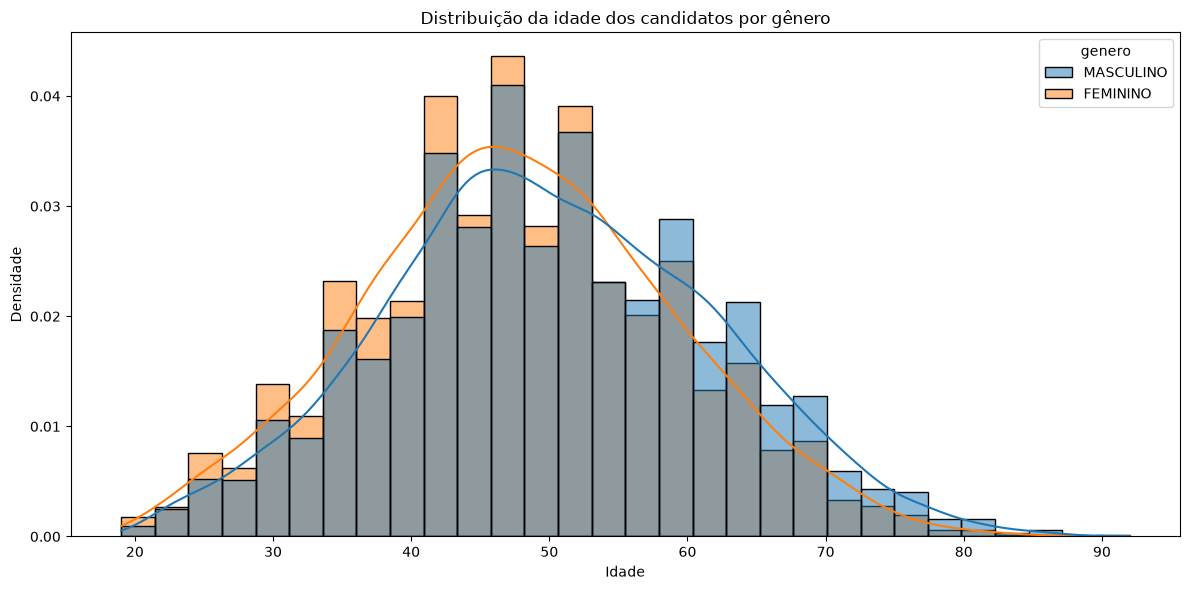

In [18]:
# Distribuição da idade por gênero

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="idade",
    hue="genero",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Distribuição da idade dos candidatos por gênero")
plt.xlabel("Idade")
plt.ylabel("Densidade")

plt.tight_layout()
plt.show()

In [19]:
# Teste t de Welch: comparação da idade média entre os gêneros

idade_feminino = df.loc[
    df["genero"] == "FEMININO",
    "idade"
]

idade_masculino = df.loc[
    df["genero"] == "MASCULINO",
    "idade"
]

estatistica, p_valor = stats.ttest_ind(
    idade_feminino,
    idade_masculino,
    equal_var=False
)

print(f"Estatística t: {estatistica:.4f}")
print(f"p-valor: {p_valor:.6f}")

Estatística t: -13.5600
p-valor: 0.000000


In [20]:
# Cálculo do tamanho do efeito (Cohen's d)

media_feminino = idade_feminino.mean()
media_masculino = idade_masculino.mean()

dp_feminino = idade_feminino.std()
dp_masculino = idade_masculino.std()

n_feminino = len(idade_feminino)
n_masculino = len(idade_masculino)

# Desvio-padrão combinado
dp_pooled = np.sqrt(
    (
        (n_feminino - 1) * dp_feminino**2
        + (n_masculino - 1) * dp_masculino**2
    )
    / (n_feminino + n_masculino - 2)
)

cohen_d = (
    (media_feminino - media_masculino)
    / dp_pooled
)

print(f"Diferença entre as médias: {media_feminino - media_masculino:.2f} anos")
print(f"Cohen's d: {cohen_d:.4f}")

Diferença entre as médias: -2.27 anos
Cohen's d: -0.1946


In [21]:
# Intervalo de confiança de 95% para a diferença entre as médias

df_welch = (
    (dp_feminino**2 / n_feminino + dp_masculino**2 / n_masculino)**2
    /
    (
        (dp_feminino**2 / n_feminino)**2 / (n_feminino - 1)
        + (dp_masculino**2 / n_masculino)**2 / (n_masculino - 1)
    )
)

erro_padrao = np.sqrt(
    dp_feminino**2 / n_feminino
    + dp_masculino**2 / n_masculino
)

diferenca = media_feminino - media_masculino

t_critico = stats.t.ppf(0.975, df_welch)

limite_inferior = diferenca - t_critico * erro_padrao
limite_superior = diferenca + t_critico * erro_padrao

print(f"Diferença média: {diferenca:.2f} anos")
print(f"IC 95%: [{limite_inferior:.2f}, {limite_superior:.2f}] anos")
print(f"Graus de liberdade de Welch: {df_welch:.2f}")

Diferença média: -2.27 anos
IC 95%: [-2.60, -1.94] anos
Graus de liberdade de Welch: 15451.41


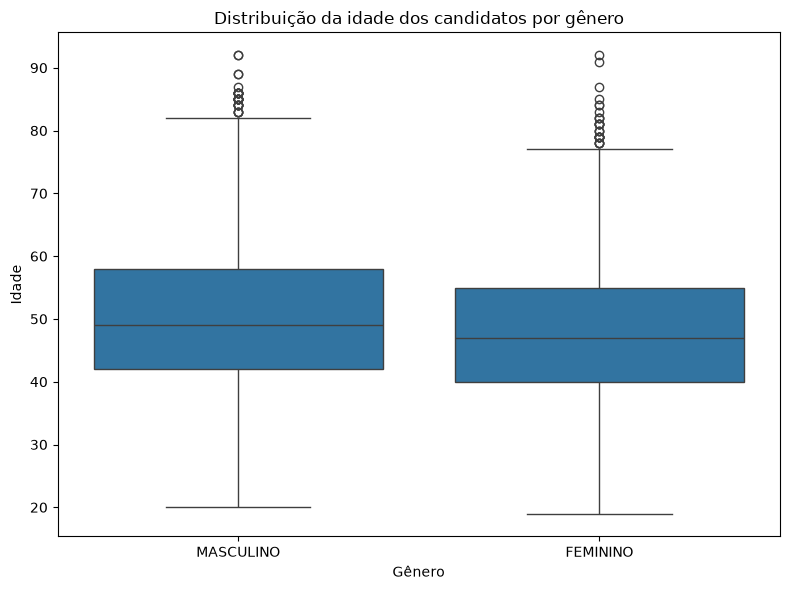

In [22]:
# Distribuição da idade por gênero

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="genero",
    y="idade"
)

plt.title("Distribuição da idade dos candidatos por gênero")
plt.xlabel("Gênero")
plt.ylabel("Idade")

plt.tight_layout()
plt.show()

In [23]:
# Estatísticas de idade por escolaridade

idade_escolaridade = (
    df.groupby("escolaridade")["idade"]
    .agg(
        Media="mean",
        Mediana="median",
        Minima="min",
        Maxima="max",
        Desvio_Padrao="std",
        Quantidade="count"
    )
    .sort_values("Media")
)

idade_escolaridade

,Media,Mediana,Minima,Maxima,Desvio_Padrao,Quantidade
escolaridade,,,,,,
SUPERIOR INCOMPLETO,44.746119,45.0,19,82,12.463319,2190
ENSINO MÉDIO INCOMPLETO,47.026316,47.0,20,78,12.401764,722
ENSINO MÉDIO COMPLETO,48.837418,49.0,20,92,11.740766,4447
SUPERIOR COMPLETO,49.917930,49.0,21,92,11.333584,12136
ENSINO FUNDAMENTAL INCOMPLETO,52.211382,53.0,22,86,11.060724,615
ENSINO FUNDAMENTAL COMPLETO,54.115672,54.0,21,86,11.216712,536
LÊ E ESCREVE,54.600000,55.0,34,81,10.383198,75


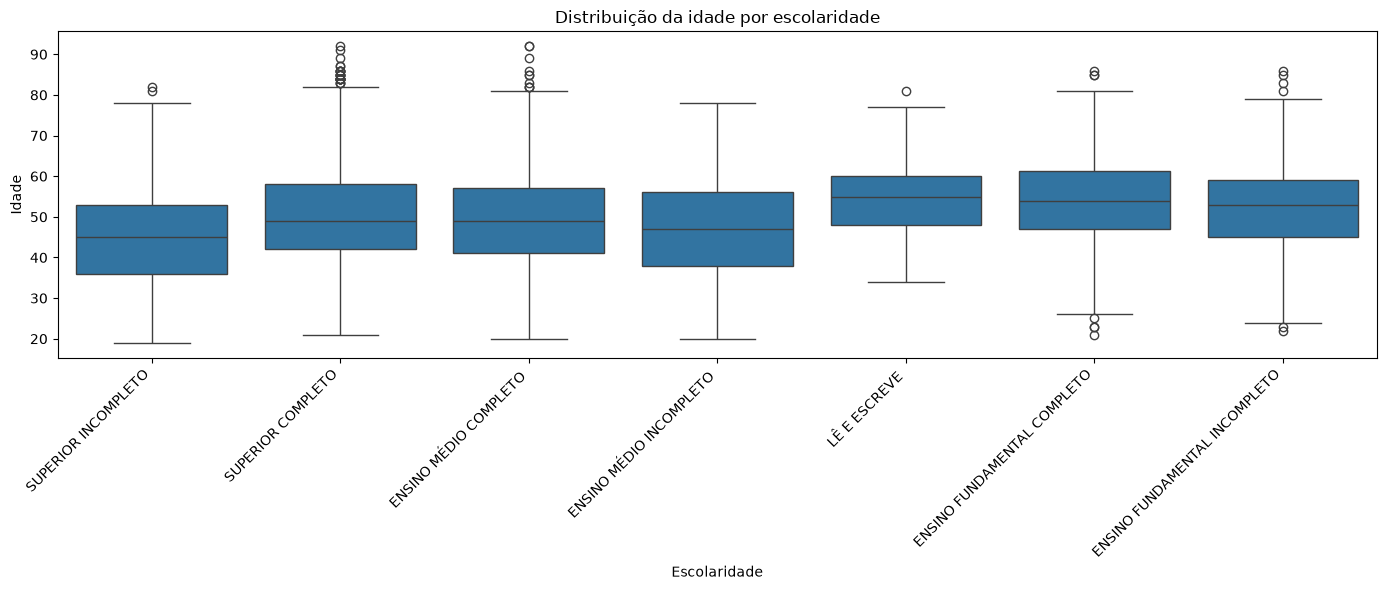

In [24]:
# Distribuição da idade por escolaridade

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="escolaridade",
    y="idade"
)

plt.title("Distribuição da idade por escolaridade")
plt.xlabel("Escolaridade")
plt.ylabel("Idade")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [25]:
# ANOVA: idade por escolaridade

grupos_escolaridade = [
    grupo["idade"].values
    for _, grupo in df.groupby("escolaridade")
]

estatistica_f, p_valor = stats.f_oneway(*grupos_escolaridade)

print(f"Estatística F: {estatistica_f:.4f}")
print(f"p-valor: {p_valor:.6f}")

Estatística F: 92.6149
p-valor: 0.000000


In [30]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
# Teste de Tukey: comparação entre os níveis de escolaridade

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df["idade"],
    groups=df["escolaridade"],
    alpha=0.05
)

print(tukey)

                        Multiple Comparison of Means - Tukey HSD, FWER=0.05                        
            group1                        group2            meandiff p-adj   lower    upper  reject
---------------------------------------------------------------------------------------------------
  ENSINO FUNDAMENTAL COMPLETO ENSINO FUNDAMENTAL INCOMPLETO  -1.9043 0.0786  -3.9202  0.1116  False
  ENSINO FUNDAMENTAL COMPLETO         ENSINO MÉDIO COMPLETO  -5.2783    0.0  -6.8381 -3.7184   True
  ENSINO FUNDAMENTAL COMPLETO       ENSINO MÉDIO INCOMPLETO  -7.0894    0.0  -9.0345 -5.1442   True
  ENSINO FUNDAMENTAL COMPLETO                  LÊ E ESCREVE   0.4843 0.9999  -3.7216  4.6903  False
  ENSINO FUNDAMENTAL COMPLETO             SUPERIOR COMPLETO  -4.1977    0.0  -5.7035  -2.692   True
  ENSINO FUNDAMENTAL COMPLETO           SUPERIOR INCOMPLETO  -9.3696    0.0 -11.0136 -7.7255   True
ENSINO FUNDAMENTAL INCOMPLETO         ENSINO MÉDIO COMPLETO   -3.374    0.0  -4.8417 -1.9062   True


In [31]:
# Tamanho do efeito da ANOVA: Eta quadrado

ss_entre = sum(
    len(grupo) * (grupo["idade"].mean() - df["idade"].mean()) ** 2
    for _, grupo in df.groupby("escolaridade")
)

ss_total = sum(
    (df["idade"] - df["idade"].mean()) ** 2
)

eta_quadrado = ss_entre / ss_total

print(f"Eta quadrado (η²): {eta_quadrado:.4f}")

Eta quadrado (η²): 0.0261


In [32]:
# Estatísticas de idade por cargo

idade_cargo = (
    df.groupby("cargo")["idade"]
    .agg(
        Media="mean",
        Mediana="median",
        Minima="min",
        Maxima="max",
        Desvio_Padrao="std",
        Quantidade="count"
    )
    .reset_index()
    .sort_values("Media")
)

idade_cargo

,cargo,Media,Mediana,Minima,Maxima,Desvio_Padrao,Quantidade
2,DEPUTADO DISTRITAL,47.993007,48.0,22,87,10.934061,429
4,DEPUTADO FEDERAL,48.763981,48.0,19,89,11.917996,7707
3,DEPUTADO ESTADUAL,49.102225,49.0,19,92,11.487659,11191
5,GOVERNADOR,50.595960,50.0,30,74,11.590666,198
8,VICE-GOVERNADOR,51.039801,50.0,30,82,12.185992,201
0,1º SUPLENTE,53.424615,52.0,33,89,12.015089,325
1,2º SUPLENTE,53.600610,52.0,31,86,12.132384,328
7,SENADOR,55.389241,56.0,35,92,11.282677,316
6,PRESIDENTE,57.461538,56.0,39,81,15.708890,13
9,VICE-PRESIDENTE,58.076923,59.0,35,73,10.618078,13


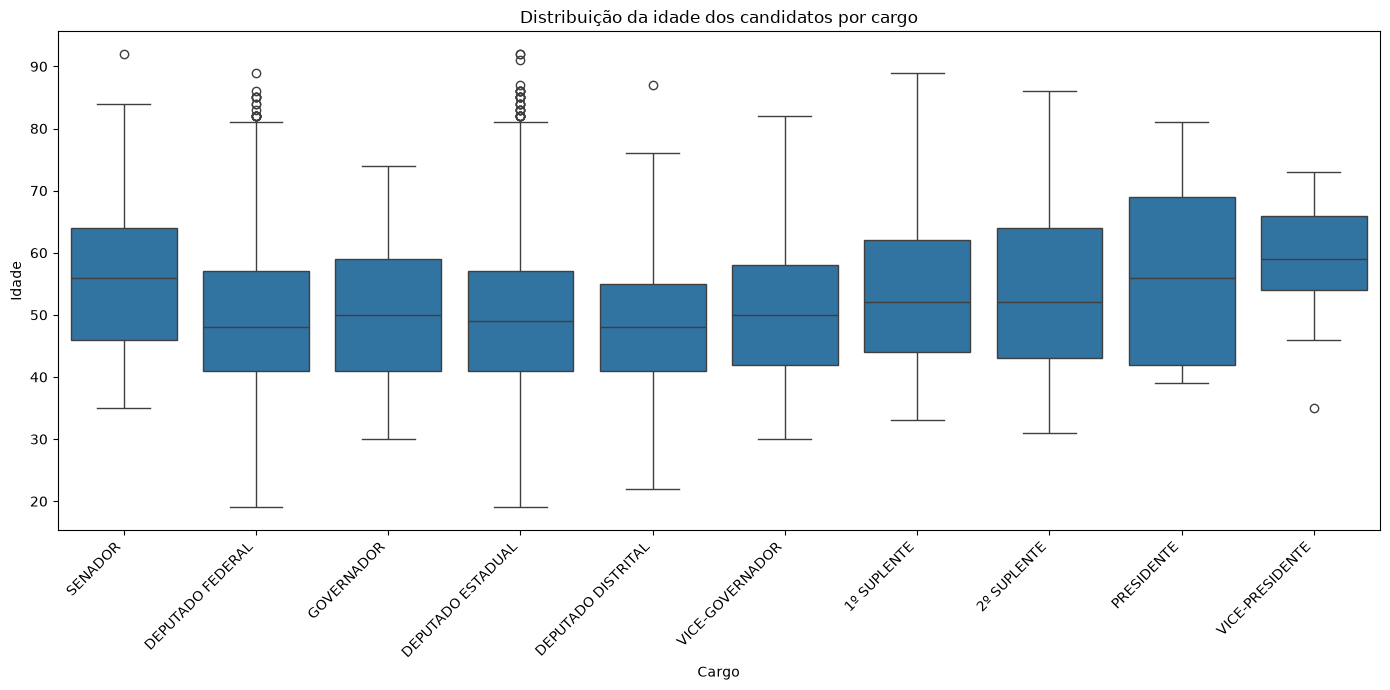

In [33]:
# Distribuição da idade por cargo

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df,
    x="cargo",
    y="idade"
)

plt.title("Distribuição da idade dos candidatos por cargo")
plt.xlabel("Cargo")
plt.ylabel("Idade")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [34]:
# ANOVA: idade por cargo

grupos_cargo = [
    grupo["idade"].values
    for _, grupo in df.groupby("cargo")
]

estatistica_f, p_valor = stats.f_oneway(*grupos_cargo)

print(f"Estatística F: {estatistica_f:.4f}")
print(f"p-valor: {p_valor:.6f}")

Estatística F: 24.0180
p-valor: 0.000000


In [35]:
# Teste de Tukey: comparação entre os cargos

tukey_cargo = pairwise_tukeyhsd(
    endog=df["idade"],
    groups=df["cargo"],
    alpha=0.05
)

print(tukey_cargo)

             Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2       meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------------------
       1º SUPLENTE        2º SUPLENTE    0.176    1.0  -2.7126  3.0646  False
       1º SUPLENTE DEPUTADO DISTRITAL  -5.4316    0.0  -8.1457 -2.7176   True
       1º SUPLENTE  DEPUTADO ESTADUAL  -4.3224    0.0  -6.3991 -2.2457   True
       1º SUPLENTE   DEPUTADO FEDERAL  -4.6606    0.0  -6.7506 -2.5707   True
       1º SUPLENTE         GOVERNADOR  -2.8287 0.1776  -6.1559  0.4986  False
       1º SUPLENTE         PRESIDENTE   4.0369 0.9688  -6.4018 14.4757  False
       1º SUPLENTE            SENADOR   1.9646 0.5047  -0.9511  4.8804  False
       1º SUPLENTE    VICE-GOVERNADOR  -2.3848 0.4031  -5.6966  0.9269  False
       1º SUPLENTE    VICE-PRESIDENTE   4.6523 0.9245  -5.7864 15.0911  False
       2º SUPLENTE DEPUTADO DISTRITAL  -5.6076    0.0  -8.3146 -

In [36]:
# Tamanho do efeito da ANOVA: Eta quadrado

ss_entre = sum(
    len(grupo) * (grupo["idade"].mean() - df["idade"].mean()) ** 2
    for _, grupo in df.groupby("cargo")
)

ss_total = sum(
    (df["idade"] - df["idade"].mean()) ** 2
)

eta_quadrado_cargo = ss_entre / ss_total

print(f"Eta quadrado (η²): {eta_quadrado_cargo:.4f}")

Eta quadrado (η²): 0.0103


In [37]:
# Distribuição de gênero por cargo

tabela_genero_cargo = pd.crosstab(
    df["cargo"],
    df["genero"]
)

tabela_genero_cargo

genero,FEMININO,MASCULINO
cargo,,
1º SUPLENTE,98,227
2º SUPLENTE,102,226
DEPUTADO DISTRITAL,151,278
DEPUTADO ESTADUAL,3861,7330
DEPUTADO FEDERAL,2821,4886
GOVERNADOR,34,164
PRESIDENTE,2,11
SENADOR,70,246
VICE-GOVERNADOR,85,116


In [38]:
# Distribuição percentual de gênero dentro de cada cargo

tabela_genero_cargo_pct = (
    pd.crosstab(
        df["cargo"],
        df["genero"],
        normalize="index"
    ) * 100
)

tabela_genero_cargo_pct

genero,FEMININO,MASCULINO
cargo,,
1º SUPLENTE,30.153846,69.846154
2º SUPLENTE,31.097561,68.902439
DEPUTADO DISTRITAL,35.198135,64.801865
DEPUTADO ESTADUAL,34.500938,65.499062
DEPUTADO FEDERAL,36.603088,63.396912
GOVERNADOR,17.171717,82.828283
PRESIDENTE,15.384615,84.615385
SENADOR,22.151899,77.848101
VICE-GOVERNADOR,42.288557,57.711443


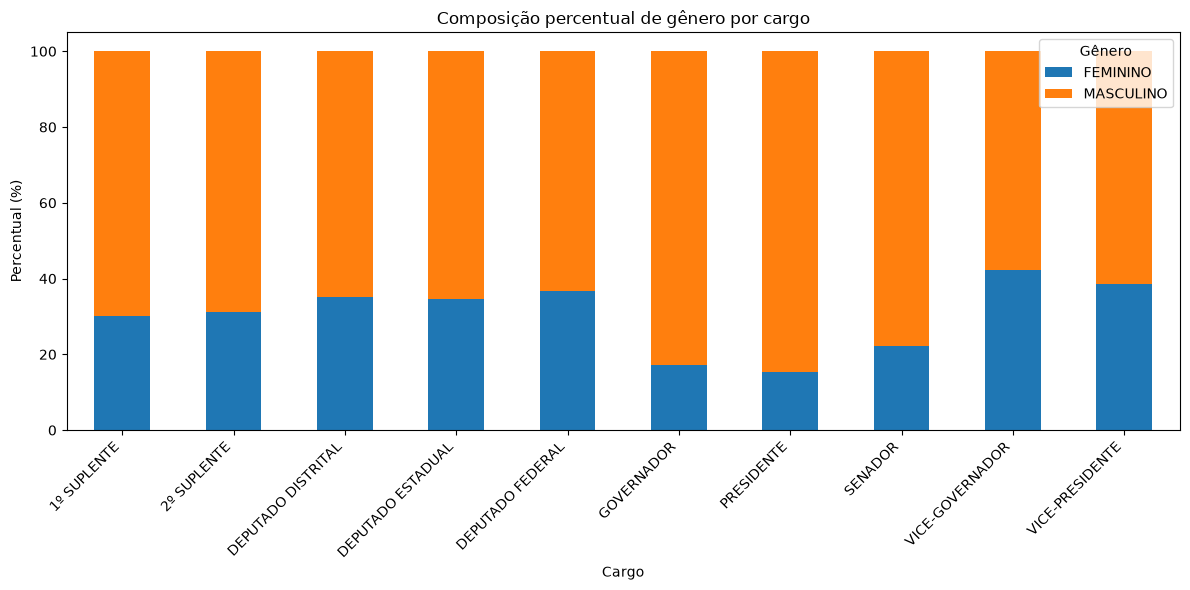

In [39]:
# Composição percentual de gênero por cargo

tabela_genero_cargo_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Composição percentual de gênero por cargo")
plt.xlabel("Cargo")
plt.ylabel("Percentual (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Gênero")

plt.tight_layout()
plt.show()

In [40]:
# Teste do qui-quadrado de independência: gênero x cargo

qui2_cargo, p_valor_cargo, graus_liberdade_cargo, frequencias_esperadas_cargo = stats.chi2_contingency(
    tabela_genero_cargo
)

print(f"Qui-quadrado: {qui2_cargo:.4f}")
print(f"p-valor: {p_valor_cargo:.6f}")
print(f"Graus de liberdade: {graus_liberdade_cargo}")

Qui-quadrado: 73.0353
p-valor: 0.000000
Graus de liberdade: 9


In [41]:
# Frequências esperadas pelo teste

tabela_esperada_cargo = pd.DataFrame(
    frequencias_esperadas_cargo,
    index=tabela_genero_cargo.index,
    columns=tabela_genero_cargo.columns
)

tabela_esperada_cargo

genero,FEMININO,MASCULINO
cargo,,
1º SUPLENTE,113.383765,211.616235
2º SUPLENTE,114.430385,213.569615
DEPUTADO DISTRITAL,149.666570,279.333430
DEPUTADO ESTADUAL,3904.239129,7286.760871
DEPUTADO FEDERAL,2688.765166,5018.234834
GOVERNADOR,69.076879,128.923121
PRESIDENTE,4.535351,8.464649
SENADOR,110.243907,205.756093
VICE-GOVERNADOR,70.123498,130.876502


In [42]:
# Tamanho do efeito: V de Cramér

n_cargo = tabela_genero_cargo.to_numpy().sum()

r_cargo, k_cargo = tabela_genero_cargo.shape

v_cramer_cargo = np.sqrt(
    qui2_cargo / (n_cargo * min(k_cargo - 1, r_cargo - 1))
)

print(f"V de Cramér: {v_cramer_cargo:.4f}")

V de Cramér: 0.0594


In [43]:
# Resíduos: gênero x cargo

residuos_cargo = (
    tabela_genero_cargo - tabela_esperada_cargo
)

residuos_cargo

genero,FEMININO,MASCULINO
cargo,,
1º SUPLENTE,-15.383765,15.383765
2º SUPLENTE,-12.430385,12.430385
DEPUTADO DISTRITAL,1.333430,-1.333430
DEPUTADO ESTADUAL,-43.239129,43.239129
DEPUTADO FEDERAL,132.234834,-132.234834
GOVERNADOR,-35.076879,35.076879
PRESIDENTE,-2.535351,2.535351
SENADOR,-40.243907,40.243907
VICE-GOVERNADOR,14.876502,-14.876502


In [44]:
# Resíduos padronizados: gênero x cargo

residuos_padronizados_cargo = (
    tabela_genero_cargo - tabela_esperada_cargo
) / np.sqrt(tabela_esperada_cargo)

residuos_padronizados_cargo

genero,FEMININO,MASCULINO
cargo,,
1º SUPLENTE,-1.444732,1.057519
2º SUPLENTE,-1.162021,0.850579
DEPUTADO DISTRITAL,0.108995,-0.079783
DEPUTADO ESTADUAL,-0.692004,0.506535
DEPUTADO FEDERAL,2.550172,-1.866682
GOVERNADOR,-4.220409,3.089268
PRESIDENTE,-1.190509,0.871432
SENADOR,-3.832859,2.805587
VICE-GOVERNADOR,1.776516,-1.300379


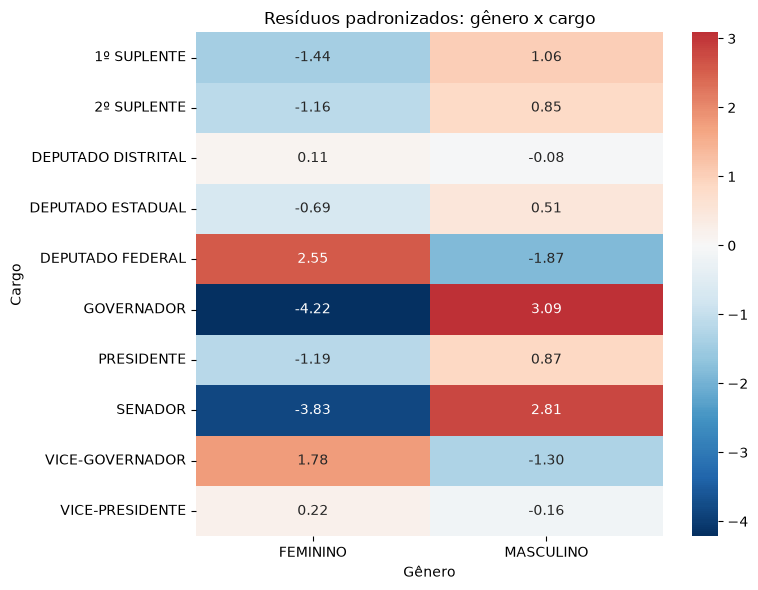

In [45]:
# Heatmap dos resíduos padronizados: gênero x cargo

plt.figure(figsize=(8, 6))

sns.heatmap(
    residuos_padronizados_cargo,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0
)

plt.title("Resíduos padronizados: gênero x cargo")
plt.xlabel("Gênero")
plt.ylabel("Cargo")

plt.tight_layout()
plt.show()

In [46]:
# Identificação dos resíduos padronizados relevantes

residuos_relevantes_cargo = residuos_padronizados_cargo[
    (residuos_padronizados_cargo.abs() > 2)
]

residuos_relevantes_cargo

genero,FEMININO,MASCULINO
cargo,,
1º SUPLENTE,NaN,NaN
2º SUPLENTE,NaN,NaN
DEPUTADO DISTRITAL,NaN,NaN
DEPUTADO ESTADUAL,NaN,NaN
DEPUTADO FEDERAL,2.550172,NaN
GOVERNADOR,-4.220409,3.089268
PRESIDENTE,NaN,NaN
SENADOR,-3.832859,2.805587
VICE-GOVERNADOR,NaN,NaN


In [47]:
# Resíduos padronizados relevantes

residuos_relevantes_cargo = (
    residuos_padronizados_cargo
    .stack()
    .reset_index()
)

residuos_relevantes_cargo.columns = [
    "cargo",
    "genero",
    "residuo_padronizado"
]

residuos_relevantes_cargo = residuos_relevantes_cargo[
    residuos_relevantes_cargo["residuo_padronizado"].abs() > 2
]

residuos_relevantes_cargo

,cargo,genero,residuo_padronizado
8,DEPUTADO FEDERAL,FEMININO,2.550172
10,GOVERNADOR,FEMININO,-4.220409
11,GOVERNADOR,MASCULINO,3.089268
14,SENADOR,FEMININO,-3.832859
15,SENADOR,MASCULINO,2.805587


In [48]:
# Resíduos padronizados relevantes

residuos_relevantes_cargo = (
    residuos_padronizados_cargo
    .stack()
    .reset_index()
)

residuos_relevantes_cargo.columns = [
    "cargo",
    "genero",
    "residuo_padronizado"
]

residuos_relevantes_cargo = residuos_relevantes_cargo[
    residuos_relevantes_cargo["residuo_padronizado"].abs() > 2
]

residuos_relevantes_cargo

,cargo,genero,residuo_padronizado
8,DEPUTADO FEDERAL,FEMININO,2.550172
10,GOVERNADOR,FEMININO,-4.220409
11,GOVERNADOR,MASCULINO,3.089268
14,SENADOR,FEMININO,-3.832859
15,SENADOR,MASCULINO,2.805587


In [49]:
# Distribuição da situação final da candidatura

df["situacao_final"].value_counts()

situacao_final
Não informado    20721
Name: count, dtype: int64

In [50]:
# Distribuição de cor/raça

df["cor_raca"].value_counts()

cor_raca
BRANCA      10281
PARDA        7320
PRETA        2818
INDÍGENA      194
AMARELA       108
Name: count, dtype: int64

In [51]:
# Tabela de frequência: cor/raça x gênero

tabela_raca_genero = pd.crosstab(
    df["cor_raca"],
    df["genero"]
)

tabela_raca_genero

genero,FEMININO,MASCULINO
cor_raca,,
AMARELA,44,64
BRANCA,3372,6909
INDÍGENA,87,107
PARDA,2475,4845
PRETA,1251,1567


In [52]:
# Composição percentual de gênero dentro de cada categoria de cor/raça

tabela_raca_genero_pct = (
    tabela_raca_genero
    .div(tabela_raca_genero.sum(axis=1), axis=0)
    * 100
)

tabela_raca_genero_pct

genero,FEMININO,MASCULINO
cor_raca,,
AMARELA,40.740741,59.259259
BRANCA,32.798366,67.201634
INDÍGENA,44.845361,55.154639
PARDA,33.811475,66.188525
PRETA,44.393187,55.606813


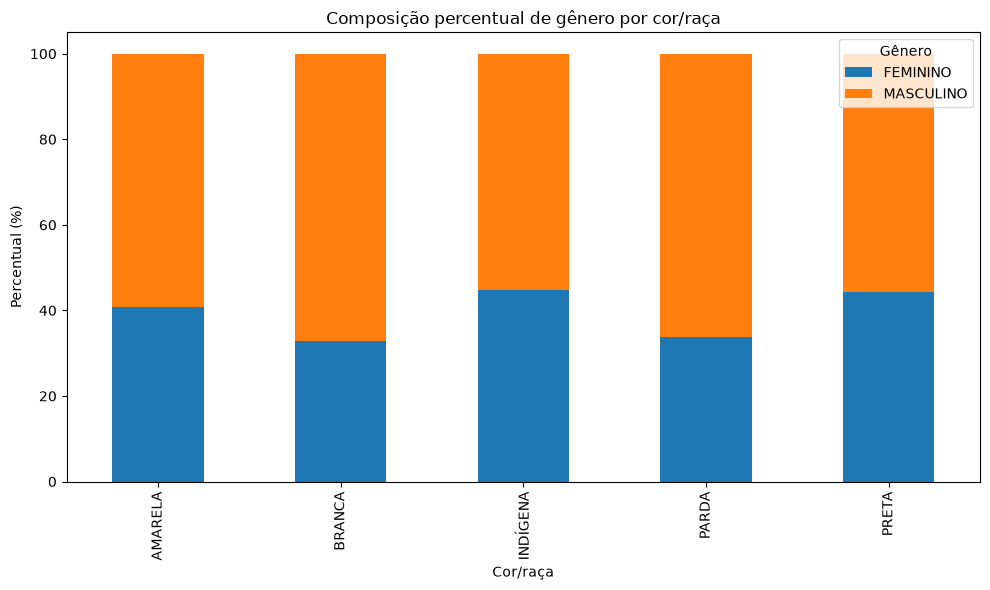

In [53]:
# Composição percentual de gênero por cor/raça

tabela_raca_genero_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Composição percentual de gênero por cor/raça")
plt.xlabel("Cor/raça")
plt.ylabel("Percentual (%)")
plt.legend(title="Gênero")

plt.tight_layout()
plt.show()

In [54]:
# Teste do qui-quadrado de independência: cor/raça x gênero

qui2_raca, p_valor_raca, graus_liberdade_raca, frequencias_esperadas_raca = stats.chi2_contingency(
    tabela_raca_genero
)

print(f"Qui-quadrado: {qui2_raca:.4f}")
print(f"p-valor: {p_valor_raca:.6f}")
print(f"Graus de liberdade: {graus_liberdade_raca}")

Qui-quadrado: 145.6734
p-valor: 0.000000
Graus de liberdade: 4


In [55]:
# Frequências esperadas pelo teste

tabela_esperada_raca = pd.DataFrame(
    frequencias_esperadas_raca,
    index=tabela_raca_genero.index,
    columns=tabela_raca_genero.columns
)

tabela_esperada_raca

genero,FEMININO,MASCULINO
cor_raca,,
AMARELA,37.678297,70.321703
BRANCA,3586.764587,6694.235413
INDÍGENA,67.681386,126.318614
PARDA,2553.751267,4766.248733
PRETA,983.124463,1834.875537


In [56]:
# Tamanho do efeito: V de Cramér

n_raca = tabela_raca_genero.to_numpy().sum()

r_raca, k_raca = tabela_raca_genero.shape

v_cramer_raca = np.sqrt(
    qui2_raca / (n_raca * min(k_raca - 1, r_raca - 1))
)

print(f"V de Cramér: {v_cramer_raca:.4f}")

V de Cramér: 0.0838


In [57]:
# Resíduos: cor/raça x gênero

residuos_raca = (
    tabela_raca_genero - tabela_esperada_raca
)

residuos_raca

genero,FEMININO,MASCULINO
cor_raca,,
AMARELA,6.321703,-6.321703
BRANCA,-214.764587,214.764587
INDÍGENA,19.318614,-19.318614
PARDA,-78.751267,78.751267
PRETA,267.875537,-267.875537


In [58]:
# Resíduos padronizados: cor/raça x gênero

residuos_padronizados_raca = (
    tabela_raca_genero - tabela_esperada_raca
) / np.sqrt(tabela_esperada_raca)

residuos_padronizados_raca

genero,FEMININO,MASCULINO
cor_raca,,
AMARELA,1.029884,-0.753858
BRANCA,-3.586008,2.624896
INDÍGENA,2.348234,-1.718867
PARDA,-1.558362,1.140694
PRETA,8.543362,-6.253595


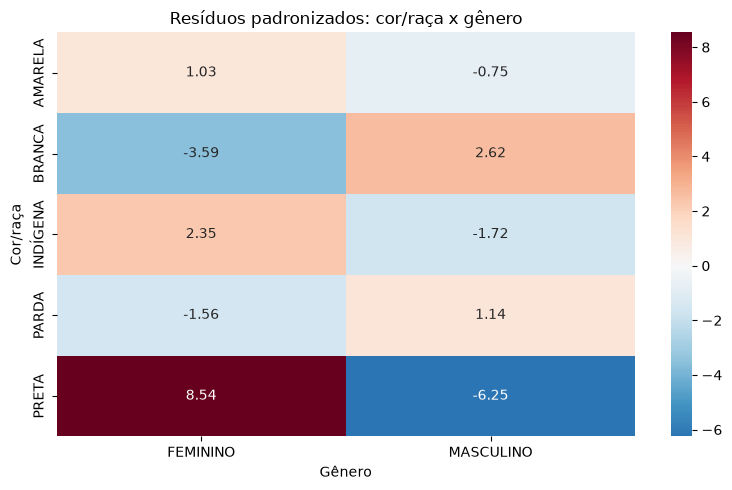

In [59]:
# Heatmap dos resíduos padronizados: cor/raça x gênero

plt.figure(figsize=(8, 5))

sns.heatmap(
    residuos_padronizados_raca,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0
)

plt.title("Resíduos padronizados: cor/raça x gênero")
plt.xlabel("Gênero")
plt.ylabel("Cor/raça")

plt.tight_layout()
plt.show()

In [60]:
# Resíduos padronizados relevantes

residuos_relevantes_raca = (
    residuos_padronizados_raca
    .stack()
    .reset_index()
)

residuos_relevantes_raca.columns = [
    "cor_raca",
    "genero",
    "residuo_padronizado"
]

residuos_relevantes_raca = residuos_relevantes_raca[
    residuos_relevantes_raca["residuo_padronizado"].abs() > 2
]

residuos_relevantes_raca

,cor_raca,genero,residuo_padronizado
2,BRANCA,FEMININO,-3.586008
3,BRANCA,MASCULINO,2.624896
4,INDÍGENA,FEMININO,2.348234
8,PRETA,FEMININO,8.543362
9,PRETA,MASCULINO,-6.253595


In [62]:
# Resumo dos principais resultados estatísticos

resumo_estatistico = pd.DataFrame({
    "Analise": [
        "Genero x escolaridade",
        "Idade x genero",
        "Idade x escolaridade",
        "Idade x cargo",
        "Genero x cargo",
        "Cor/raca x genero"
    ],

    "Teste": [
        "Qui-quadrado",
        "Teste t de Welch",
        "ANOVA",
        "ANOVA",
        "Qui-quadrado",
        "Qui-quadrado"
    ],

    "Estatistica": [
        26.2478,
        -13.5600,
        92.6149,
        24.0180,
        73.0353,
        145.6734
    ],

    "p_valor": [
        "< 0.001",
        "< 0.001",
        "< 0.001",
        "< 0.001",
        "< 0.001",
        "< 0.001"
    ],

    "Tamanho_efeito": [
        "V = 0.0356",
        "d = -0.1946",
        "η² = 0.0261",
        "η² = 0.0103",
        "V = 0.0594",
        "V = 0.0838"
    ]
})

resumo_estatistico

,Analise,Teste,Estatistica,p_valor,Tamanho_efeito
0,Genero x escolaridade,Qui-quadrado,26.2478,< 0.001,V = 0.0356
1,Idade x genero,Teste t de Welch,-13.5600,< 0.001,d = -0.1946
2,Idade x escolaridade,ANOVA,92.6149,< 0.001,η² = 0.0261
3,Idade x cargo,ANOVA,24.0180,< 0.001,η² = 0.0103
4,Genero x cargo,Qui-quadrado,73.0353,< 0.001,V = 0.0594
5,Cor/raca x genero,Qui-quadrado,145.6734,< 0.001,V = 0.0838
